In [2]:
path = "/lustre/LHCb/carlos.arenas/data/v009_pmu7-fn0k-fc0-ww3_inelastic_none_1_1e4.hepmc"

with open(path, "r") as file:
    lines = file.readlines()
    print(len(lines))

event_lines = []
for i, line in enumerate(lines):
    values = line.split(" ")

    if values[0] == "E":
        event_id = int(values[1])

        event_lines.append([event_id, i])

event_lines.append([0, len(lines)])

print(f"Hay {len(event_lines) - 1} eventos")
for i in event_lines:
    print(i)

300272
Hay 90 eventos
[33756, 8]
[50793, 2349]
[50794, 6230]
[78259, 6253]
[80364, 11070]
[98261, 13938]
[105773, 17270]
[138779, 22262]
[220944, 26870]
[225119, 32735]
[225909, 36757]
[229912, 41653]
[231105, 44566]
[232979, 46188]
[243548, 49090]
[243714, 53045]
[269535, 59790]
[289641, 62663]
[300843, 66928]
[341502, 70112]
[352515, 73344]
[376670, 75326]
[379247, 77682]
[379248, 80835]
[386128, 80849]
[400639, 85487]
[429213, 87102]
[466268, 88786]
[471211, 94202]
[473776, 95718]
[485128, 99556]
[499854, 102928]
[506489, 105153]
[507351, 105184]
[510085, 111538]
[533160, 114566]
[585802, 119452]
[585804, 123088]
[603701, 123101]
[630726, 126516]
[641045, 128828]
[641046, 133523]
[689579, 133539]
[714638, 136759]
[771123, 141643]
[772432, 146707]
[777456, 151995]
[813101, 156229]
[813102, 156249]
[816921, 156257]
[837133, 159908]
[863131, 165795]
[896258, 170474]
[956218, 173713]
[973314, 177415]
[1001303, 181259]
[1014390, 185463]
[1026871, 189698]
[1093110, 191742]
[1130470, 19283

In [3]:
pdg_id_dicc = {13: r"$\mu^-$", 22:r"$\gamma$", 111: r"$\pi^0$", 130:r"$KL_0$", 211: r"$\pi^+$", 310:r"$K_S0$", 321: r"K^+",
                2112: "n", 2212: r"$p^+$"}

def text2list(text):

    # Elimina los espacios blancos.
    import re
    text = re.sub(r"\s+", "", text)

    text = text[1:-1]
    l = text.split(",")

    if l == ['']:
        # print(f"Este venia vacio: {text}")
        return []
    
    try:
        l = [int(x) for x in l]
    except:
        print(f"Exception ocurred with: {l}")
        return None
    
    return l

def for_all_events(func):
    def looped_func():
        for i in range(len(event_lines) - 1):
            event_id = event_lines[i][0]
            start_line = event_lines[i][1]
            end_line = event_lines[i+1][1]

            func(event_id, start_line, end_line)
        return

    return looped_func

def for_single_event(func):
    def func_event1():
        global event_nr
        event_id = event_lines[event_nr][0]
        start_line = event_lines[event_nr][1]
        end_line = event_lines[event_nr+1][1]
        func(event_id, start_line, end_line)
        return
    return func_event1

In [4]:
def fill_dicc(event_id, start_line, end_line):
    global vertices_particles
    global particles_vertex
    global particles_pid
    global particles_nhit

    global vertices_location
    global particles_momenta

    vertices_particles.clear()
    particles_vertex.clear()
    particles_pid.clear()
    particles_nhit.clear()

    vertices_location.clear()
    particles_momenta.clear()

    vertices_particles[0] = []
    vertices_location[0] = None

    for i in range(end_line - start_line):
        line = lines[start_line + i]
        values = line.split(" ")

        if values[0] == "V":
            vertex_id = int(values[1])
            vertex_particles = text2list(values[3])
            
            # vertices_particles.append([vertex_id, vertex_particles])
            vertices_particles[vertex_id] = vertex_particles

            try:
                x = float(values[5])
                y = float(values[6])
                z = float(values[7])
                vertices_location[vertex_id] = [x, y, z]
            except:
                vertices_location[vertex_id] = None
                
        if values[0] == "P":
            particle_id = int(values[1])
            vertex_id = int(values[2])
            pdg_id = int(values[3])

            particles_vertex[particle_id] = vertex_id
            particles_pid[particle_id] = pdg_id

            px = float(values[4])
            py = float(values[5])
            pz = float(values[6])

            particles_momenta[particle_id] = [px, py, pz]

        if values[0] == "A":
            if values[2] == "RawBankLinks":
                particle_id = int(values[1])
                particle_banks = values[3:-1]
                particle_nhit = len(particle_banks)

                particles_nhit[particle_id] = particle_nhit

def fill_directed_vertices_links():
    global directed_vertices_links
    global birth_death_dicc

    directed_vertices_links.clear()
    birth_death_dicc.clear()

    # Con sets ya no me tengo que preocupar de que haya duplicados
    directed_vertices_links = {vertex: set() for vertex in vertices_particles}
    directed_vertices_links[0] = set()

    for vertex, particles in vertices_particles.items():
        for particle in particles:
            mother_vertex = particles_vertex[particle]

            directed_vertices_links[mother_vertex].add(vertex)

            birth_death_dicc[particle] = [mother_vertex, vertex]

    for particle, vertex in particles_vertex.items():
        if not particle in birth_death_dicc.keys():
            birth_death_dicc[particle] = [vertex, None]

def fill_vertices_output():
    global mother_vertices

    global vertices_output

    vertices_output.clear()

    vertices_output = {vertex: [] for vertex in vertices_particles}

    for vertex in mother_vertices:
        vertices_output[vertex] = []

    for particle, vertex in particles_vertex.items():
        vertices_output[vertex].append(particle)

In [5]:
def for_all_vertices_in_chain(upon_visite_func):
    def looped_func(obj, starting_vertex = 0):
        global directed_vertices_links

        visited_vertices = {vertex: 0 for vertex in vertices_particles}
        visited_vertices[0] = 0

        def visitar(obj, vertex):
            # print("Se esta visitando algo")
            visited_vertices[vertex] = 1
            current_chain.append(vertex)

            skip = upon_visite_func(obj, vertex)
            if skip: return

            for daughter_vertex in directed_vertices_links[vertex]:
                if visited_vertices[daughter_vertex] == 0:
                    visitar(obj, daughter_vertex)

        visitar(obj, starting_vertex)

    return looped_func

class counter():
    def __init__(self):
        self.value = 0

@for_all_vertices_in_chain
def sum_hits(hit_counter, this_vertex):
    # print("Se esta haciendo algo")
    for particle in vertices_output[this_vertex]:
        # print("Se esta haciendo algo")
        try:
            nhit = particles_nhit[particle]
            hit_counter.value += nhit
        except KeyError:
            pass

    skip = False
    return skip

@for_all_vertices_in_chain
def count_KS_hits(KS_hits, current_vertex):

    skip = False
    for particle in vertices_particles[current_vertex]:
        # print("Se esta haciendo algo")
        if particles_pid[particle] == 310:
            # print("Se encontró kei short")
            skip = True

            hit_counter = counter()
            sum_hits(hit_counter, current_vertex)
            KS_hits.append(hit_counter.value) # Igual, problema de scope

    return skip

@for_all_vertices_in_chain
def count_KS(KS_counter, vertex):
    skip = False
    for particle in vertices_particles[vertex]:
        # print("Se esta haciendo algo")
        if particles_pid[particle] == 310:
            skip = True

            KS_counter.value += 1
            
    return skip

@for_all_vertices_in_chain
def plot_particles(ax, vertex):
    import numpy as np
    global particles_momenta
    # Faltarían mas variables globales por incluir, pero bué

    for particle in vertices_output[vertex]:
        death_vertex = birth_death_dicc[particle][1]

        if death_vertex != None:
            start_point = vertices_location[vertex]
            end_point = vertices_location[death_vertex]

            if start_point != None and end_point != None:
                sp = np.array(start_point)/1000
                ep = np.array(end_point)/1000

                ax.plot([sp[0], ep[0]], [sp[1], ep[1]], linestyle = "--", alpha = 0.7)

        else:
            start_point = vertices_location[vertex]

            if start_point != None:

                momentum = particles_momenta[particle]
                module = np.sqrt(momentum[0]**2 + momentum[1]**2 + momentum[2]**2)

                sp = np.array(start_point)/1000
                ep = sp + np.array(momentum)/module

                ax.plot([sp[0], ep[0]], [sp[1], ep[1]], linestyle = "--", alpha = 0.7)


    skip = False
    return skip

@for_all_vertices_in_chain
def find_all_KS0(KS0_ids, vertex):
    for particle in vertices_particles[vertex]:
        if particles_pid[particle] == 310:
            KS0_ids.append(particle)

    skip = False
    return skip

def plot_all_KS0(ax):
    KS0_ids = []
    find_all_KS0(KS0_ids, 0)

    for particle in KS0_ids:
        death_vertex = birth_death_dicc[particle][1]
        plot_particles(ax, death_vertex)

In [6]:
def choose_particles_to_plot():
    pass

In [7]:
import sys
sys.path.insert(0, "cobra/src")           # so Python can find the cobra package
from cobra import load_detector_from_yaml
from cobra.geometry import transform_surface

detector = load_detector_from_yaml("/lustre/LHCb/carlos.arenas/cobra/config/codex-beta.yaml")

/lustre/LHCb/carlos.arenas/cobra/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import pyhepmc
import numpy as np
from cobra import StripDecoder
from cobra.geometry import transform_surface
from cobra.geometry import strip_to_global_position

def strip_points(detector, strips):
    points = []
    for module_id in {int(r[0]) for r in strips}:      # go module by module...
        module = detector.modules[module_id]
        for slot in range(3):                           # ...and singlet by singlet within the module
            here = [r for r in strips if int(r[0]) == module_id and int(r[1]) == slot]
            phi_strips = [int(r[2]) for r in here if int(r[4]) == 0]
            eta_strips = [int(r[2]) for r in here if int(r[4]) == 1]
            singlet = detector.singlets[module.singlet_ids[slot]]
            for phi in phi_strips:
                for eta in eta_strips:
                    point = strip_to_global_position(detector, module, singlet, eta_strip=eta, phi_strip=phi)
                    points.append(point)
    return np.array(points)

def get_hit_points(event_nr):
    with pyhepmc.open(path) as f:
        it = iter(f)
        for i in range(event_nr):
            next(it)
        event = next(it)

    rows = []
    for key, value in event.attributes.items():
        if key.startswith("RawBank_"):
            module, strip, time0, time1 = [int(x) for x in str(value).split()]
            rows.append([0, module, strip, time0, time1])           # 0 = sourceID placeholder

    raw_banks = np.array(rows, dtype=np.int16)
    strips = StripDecoder()._process(raw_banks)

    points = strip_points(detector, strips.tolist())

    return points

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_detector(ax, view = "front", zoom = "zoom_in"):
    for module in detector.modules.values():
        corners = np.vstack([transform_surface(detector, module, detector.singlets[s]) for s in module.singlet_ids])
        lo, hi = corners.min(axis=0), corners.max(axis=0)
        if view == "front":
            ax.add_patch(plt.Rectangle((lo[0], lo[1]), hi[0] - lo[0], hi[1] - lo[1], facecolor="lightgreen", alpha=0.3))
        elif view == "side":
            ax.add_patch(plt.Rectangle((lo[0], lo[2]), hi[0] - lo[0], hi[2] - lo[2], facecolor="lightgreen", alpha=0.3))

    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_box_aspect(1)

    if zoom == "zoom_in":
        ax.set_xlim(left= 29, right= 33)
        ax.set_ylim(bottom= -6, top= -3)
    elif zoom == "zoom_medium":
        ax.set_xlim(left= 25, right= 33)
        ax.set_ylim(bottom= -6, top= -2)
    elif zoom == "zoom_out":
        ax.set_xlim(left=-10, right=32)
        ax.set_ylim(bottom=-10, top=25)

In [10]:
def get_start_end_points(particle):
    global particles_vertex
    global vertices_location
    global birth_death_dicc

    mother_vertex = particles_vertex[particle]
    start_point = vertices_location[mother_vertex]

    death_vertex = birth_death_dicc[particle][1]
    if death_vertex != None:
        end_point = vertices_location[death_vertex]
    else:
        momentum = particles_momenta[particle]
        module = np.sqrt(momentum[0]**2 + momentum[1]**2 + momentum[2]**2)

        sp = np.array(start_point)/1000
        ep = sp + 2*np.array(momentum)/module

    return sp, ep

In [28]:
vertices_particles = {}
particles_vertex = {}
particles_pid = {}
particles_nhit = {}

vertices_location = {}
particles_momenta = {}

directed_vertices_links = {}
birth_death_dicc = {}

mother_vertices = []

vertices_input = []
vertices_output = {}

current_chain = []
chains = []
current_chain_hits = 0
chains_hits = []

KS_hits = []
KS_count = 0

event_nr = 1

@for_single_event
def main(event_id, start_line, end_line):

    fill_dicc(event_id, start_line, end_line)

    fill_directed_vertices_links()
    fill_vertices_output()

    # print(find_mother_particles_pid())

    # count_hits_per_chain()
    hit_counter = counter()
    sum_hits(hit_counter, 0)
    print(hit_counter.value)
    chains_hits.append(hit_counter.value)
    chains.append(current_chain)

    global KS_hits
    count_KS_hits(KS_hits, 0)
    print(KS_hits)

    KS_counter = counter()
    count_KS(KS_counter, 0)
    print(f"Hay: {KS_counter.value} K shorts")



    # Preparacion del plotteo
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axs = plt.subplots(1,2)
    plot_detector(axs[0], zoom = "zoom_medium")
    plot_detector(axs[1], zoom = "zoom_medium")

    # ax.set_xlim(left=-10, right=32)
    # ax.set_ylim(bottom=-10, top=25)

    # ax.set_xlim(left=-0.2, right=0.2)
    # ax.set_ylim(bottom=-0.2, top=0.2)

    # plt.savefig("event_alzado.png")

    global event_nr
    points = get_hit_points(event_nr)
    axs[0].scatter(points[:,0], points[:,1])
    axs[0].set_title("Todas las partículas")
    axs[1].scatter(points[:,0], points[:,1])
    axs[1].set_title("Partículas con hits")

    plot_particles(axs[0], 0)

    for particle in particles_nhit:
        print(particles_pid[particle])

        mother_vertex = particles_vertex[particle]
        print(vertices_particles[mother_vertex])

        sp, ep = get_start_end_points(particle)
        axs[1].plot([sp[0], ep[0]], [sp[1], ep[1]], linestyle = "--", alpha = 0.7)


    
    # fig, ax = plt.subplots()
    # plot_particles(ax, 0)
    # plot_all_KS0(ax)
    plt.show()

    print([particles_pid[particle] for particle in vertices_output[0]])

    print(f"El evento {event_id} tiene {len(vertices_particles)} vértices y {chains_hits[-1]} hits")

217
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Hay: 34 K shorts
-11
[2647]
-11
[2657]
11
[2677]
211
[2695]
11
[2703]
-11
[2709]
11
[2713]
11
[2737]
11
[2739]
11
[2745]
11
[2747]


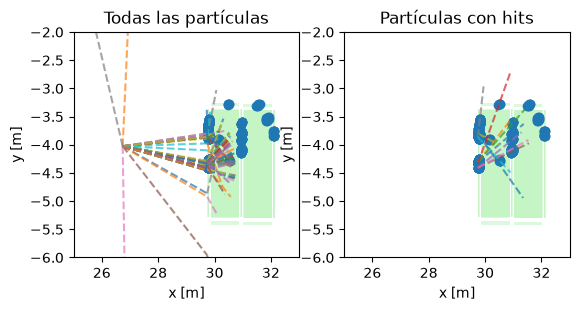

[2212, 2212, 2212, 2212, 2212, 2212, 2212, 2212, 2212, 2212, 2212, 2212, 2212, 2212, 2212, 2212]
El evento 50793 tiene 953 vértices y 217 hits


In [29]:
main()

In [ ]:
for particle, pid in particles_pid.items():
    if birth_death_dicc[particle][1] == None:
        try:
            print(pdg_id_dicc[pid])
        except:
            print(f"Unkown ({pid})")

$\pi^+$
Unkown (-211)
Unkown (-211)
Unkown (-211)
K^+
$\pi^+$
Unkown (-321)
Unkown (-211)
$\pi^+$
Unkown (-321)
Unkown (-211)
$\pi^+$
Unkown (-211)
$\pi^+$
Unkown (-211)
Unkown (-211)
$\pi^+$
Unkown (-211)
$p^+$
$\pi^+$
Unkown (-211)
$\pi^+$
Unkown (-211)
$\pi^+$
Unkown (-321)
n
$\pi^+$
Unkown (-2212)
$p^+$
Unkown (-211)
Unkown (-211)
K^+
Unkown (-211)
$\pi^+$
$\pi^+$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
Unkown (-211)
$\pi^+$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\pi^+$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
Unkown (-211)
$\pi^+$
Unkown (-211)
$\pi^+$
Unkown (-211)
$p^+$
Unkown (-211)
$\pi^+$
$\gamma$
$\gamma$
$\pi^+$
$\gamma$
$\gamma$
$\pi^+$
Unkown (-2112)
Unkown (-211)
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
Unkown (-211)
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\gamma$
$\pi^+$
$\gamma$
$\gamma$
$\gamma$
$KL_0$
Unkown (-211)
$\pi^+$
$\gamma$
$\gamma$
$\gamma$
$\g

In [ ]:
for particle in particles_nhit:
    print(particles_pid[particle])

211
11


In [ ]:
@for_single_event
def print_raw_bank_links(event_id, start_line, end_line):
    for line in lines[start_line:end_line]:
        values = line.split()

        if values[0] == "A":
            if values[2] == "RawBankLinks":
                print(line)

            if values[2].startswith("RawBank_"):
                print(line)

print_raw_bank_links()
print(particles_nhit)

A 2648 RawBankLinks -26 -41 48 -51 -52 -60 -65 -69 72 76 92 101 119 -124 138 146 150 -157

A 2658 RawBankLinks -51 -52 -60 67 -69 -80 98 102 119 -124 138 147

A 2678 RawBankLinks -21 31 32 39 43 -47 48 49 -51 -52 53 57 -60 -61 -64 -69 -78 -80 81 92 104 -132 138 -142

A 2696 RawBankLinks -22 24 -27 -28 34 45 48 -52 53 -58 -60 67 -69 -80 92 135 138

A 2704 RawBankLinks 18 -19 -20 36 -44 48 50 59 62 -68 -69 -71 79 -84 -89 92 94 -97 98 100 103 105 110 119 120 -123 -124 -133 148

A 2710 RawBankLinks 18 -20 -29 -36 -44 -46 48 65 -69 85 91 92 -99 -101 107 108 112 -113 -114 115 119 -124 -130 143 -150 157

A 2714 RawBankLinks 18 -20 -36 -44 -46 48 -69 84 85 91 92 107 108 112 115 -118 119 122 -124 -127 -128 129 -153

A 2738 RawBankLinks -25 -40 -63 -66 73 75 82 83 87 90 93 -95 -111 116 117 121 126 -131 -134 -136 -137 -139 -140 -141 -144 -145 149 151 152 154 155 156

A 2740 RawBankLinks 14 -16 -17 38 42 54 56 -86 88 96 -109 116 117 -125 149 151 155 -158

A 2746 RawBankLinks 4 5 7 -9 10 -11 -12 13

In [8]:
hist_hits = []

def contar_hits_KS(hist_hits):
    for particle, pdg_id in particles_pid.items():
        if pdg_id == 111:
            try:
                nhit = particles_nhit[particle]
                if nhit != 0:
                    hist_hits.append(nhit)
            except:
                pass

@for_all_events
def main2(event_nr, start_line, end_line):
    fill_dicc(event_nr, start_line, end_line)
    contar_hits_KS(hist_hits)

main2()
print(hist_hits)

import matplotlib.pyplot as plt

plt.hist(hist_hits)

plt.xlabel('Number of hits')
plt.ylabel('Number of particles')
plt.title(r"PID: 111, $\pi^0$")

plt.show()

NameError: name 'vertices_particles' is not defined